# QRF Wheat Yield Prediction 

| | |
|---|---|
| Training windows | 5 (1989–2016 through 1989–2020) |
| Test years | 2017–2021 |
| Features   | pre-sowing rainfall, early season rainfall, late season rainfall, incrop growing degree days, days belows 2 degrees and above 32 degrees during flowing stage, ph_0_30, ph_30_60, pawc_0_30_cm, pawc_0_60_cm 

---

# Questions
- Do the 90% predicted inverval cover the APSIM estimated yield?

- Is the model over-estimate or under-estimate the APSIM estimate yield? Does the bias vary with yield magnitude? 

- Does the model bias vary across Australian statees?



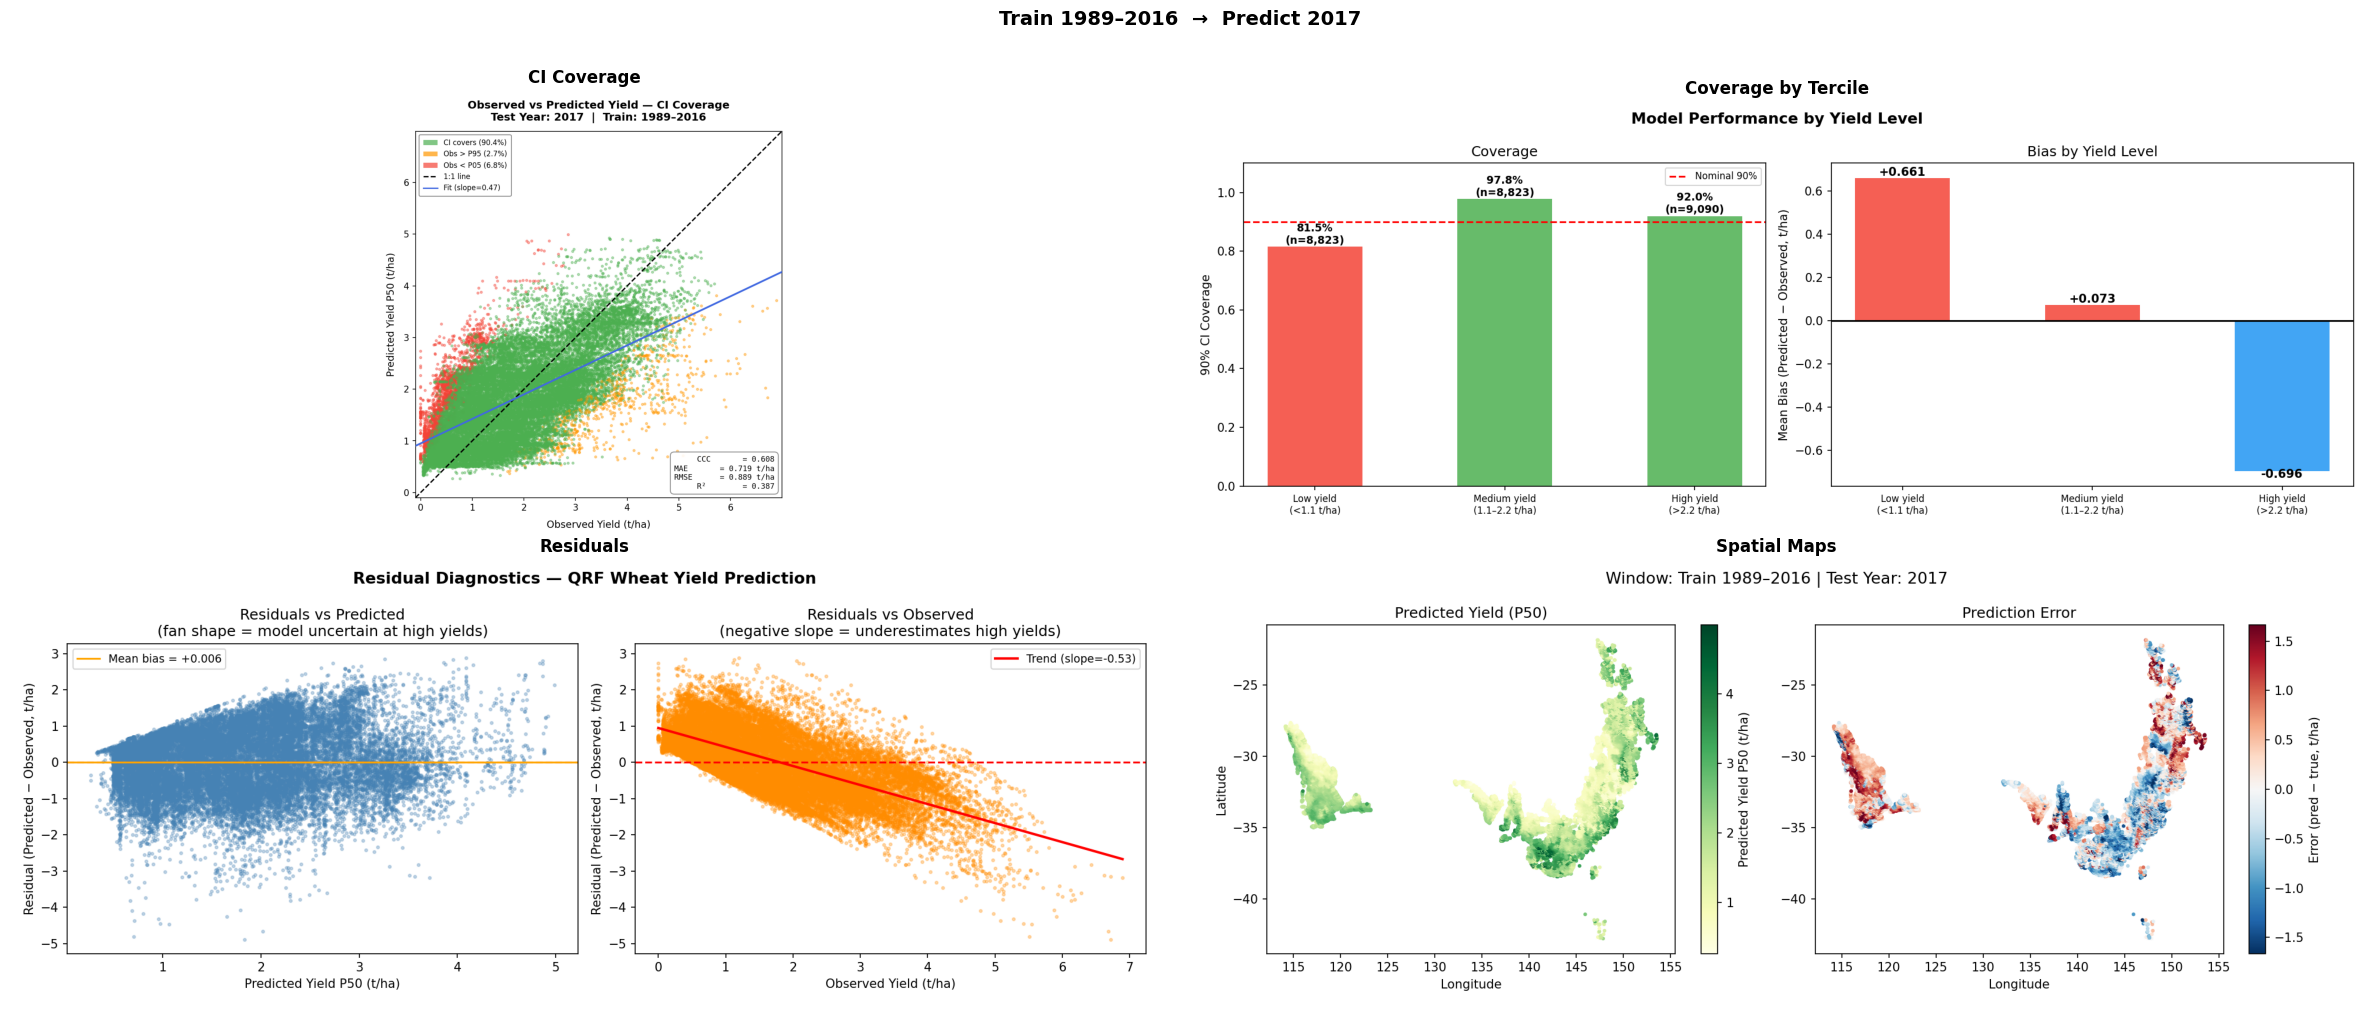

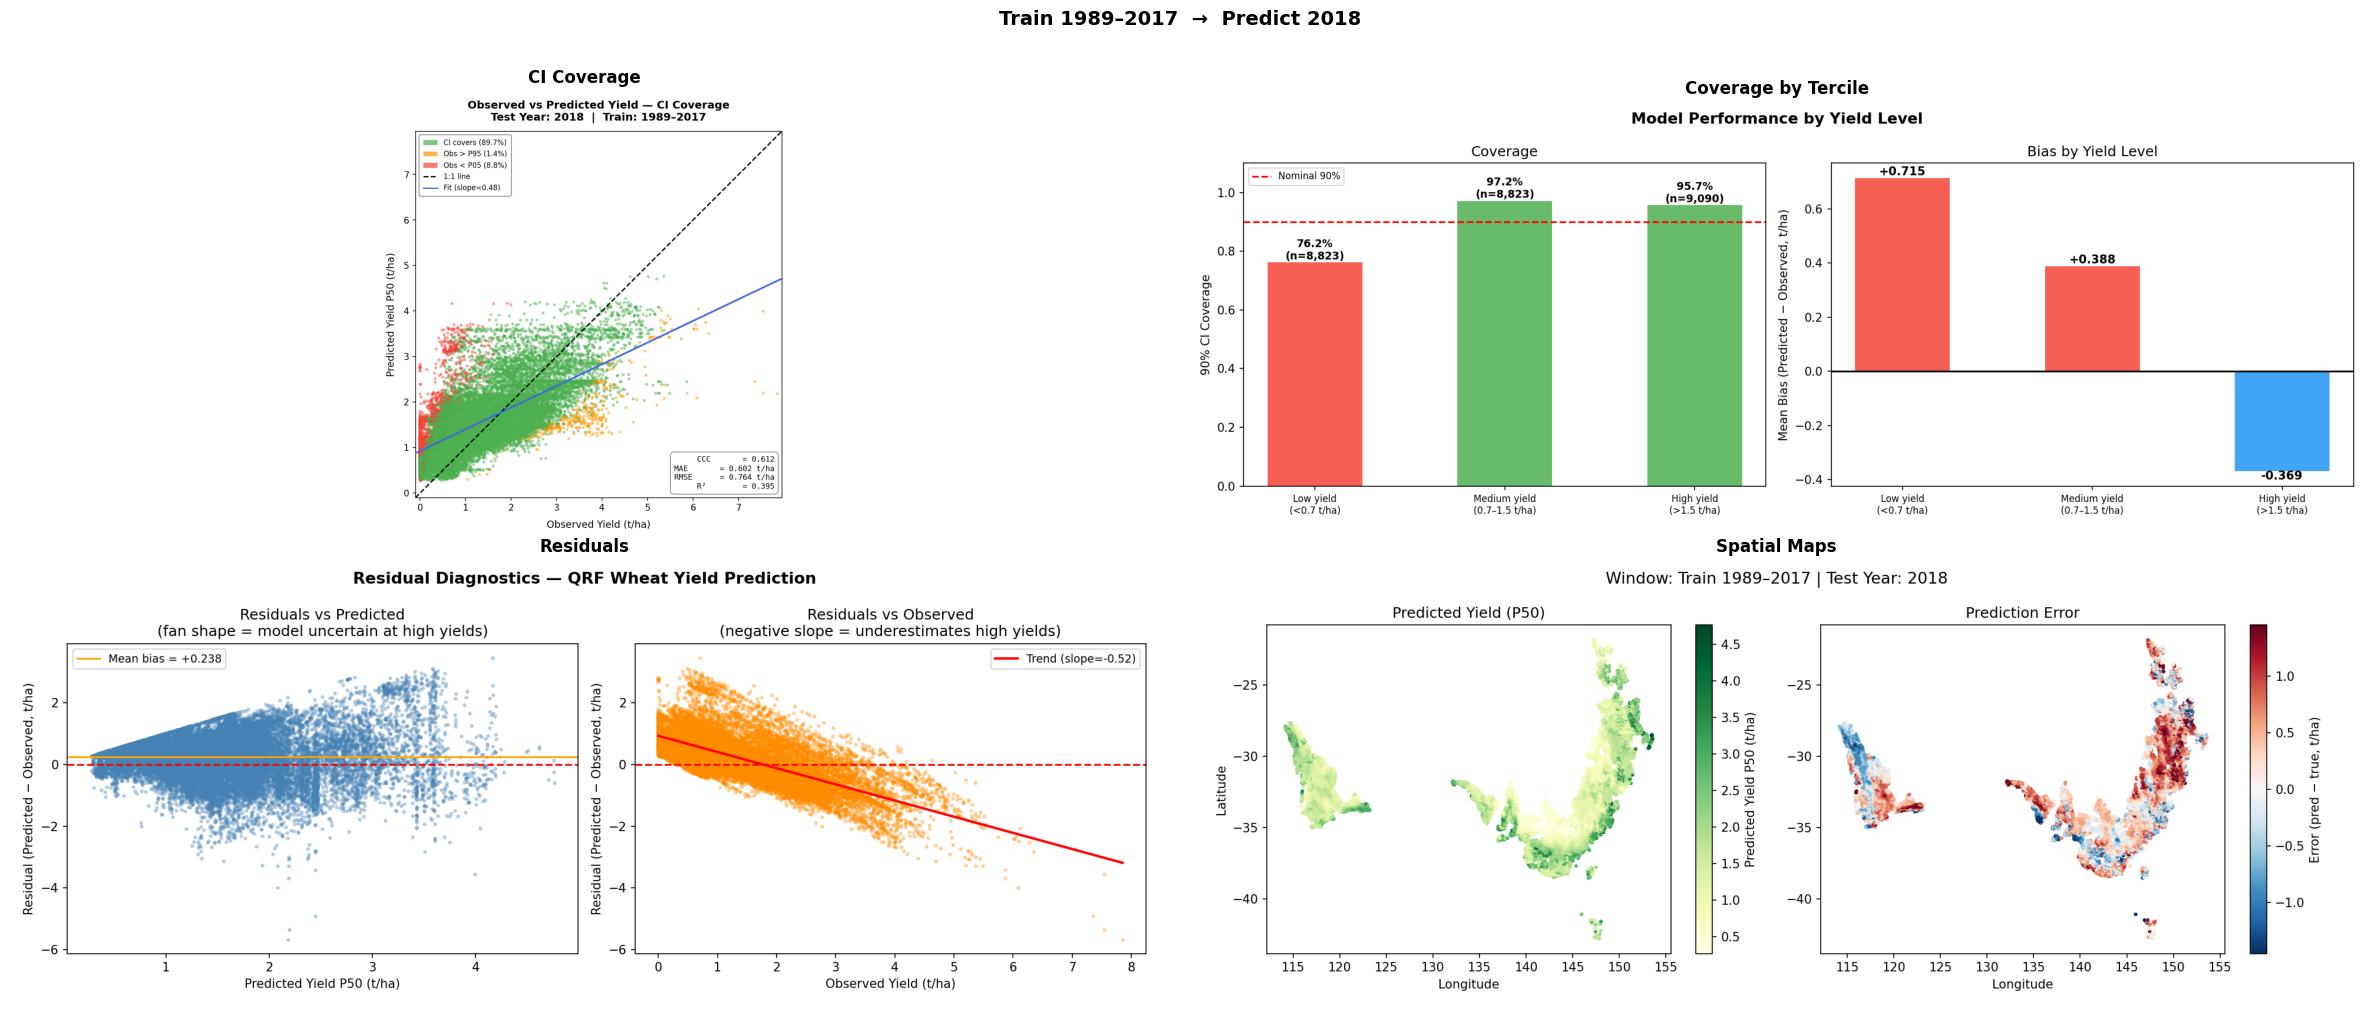

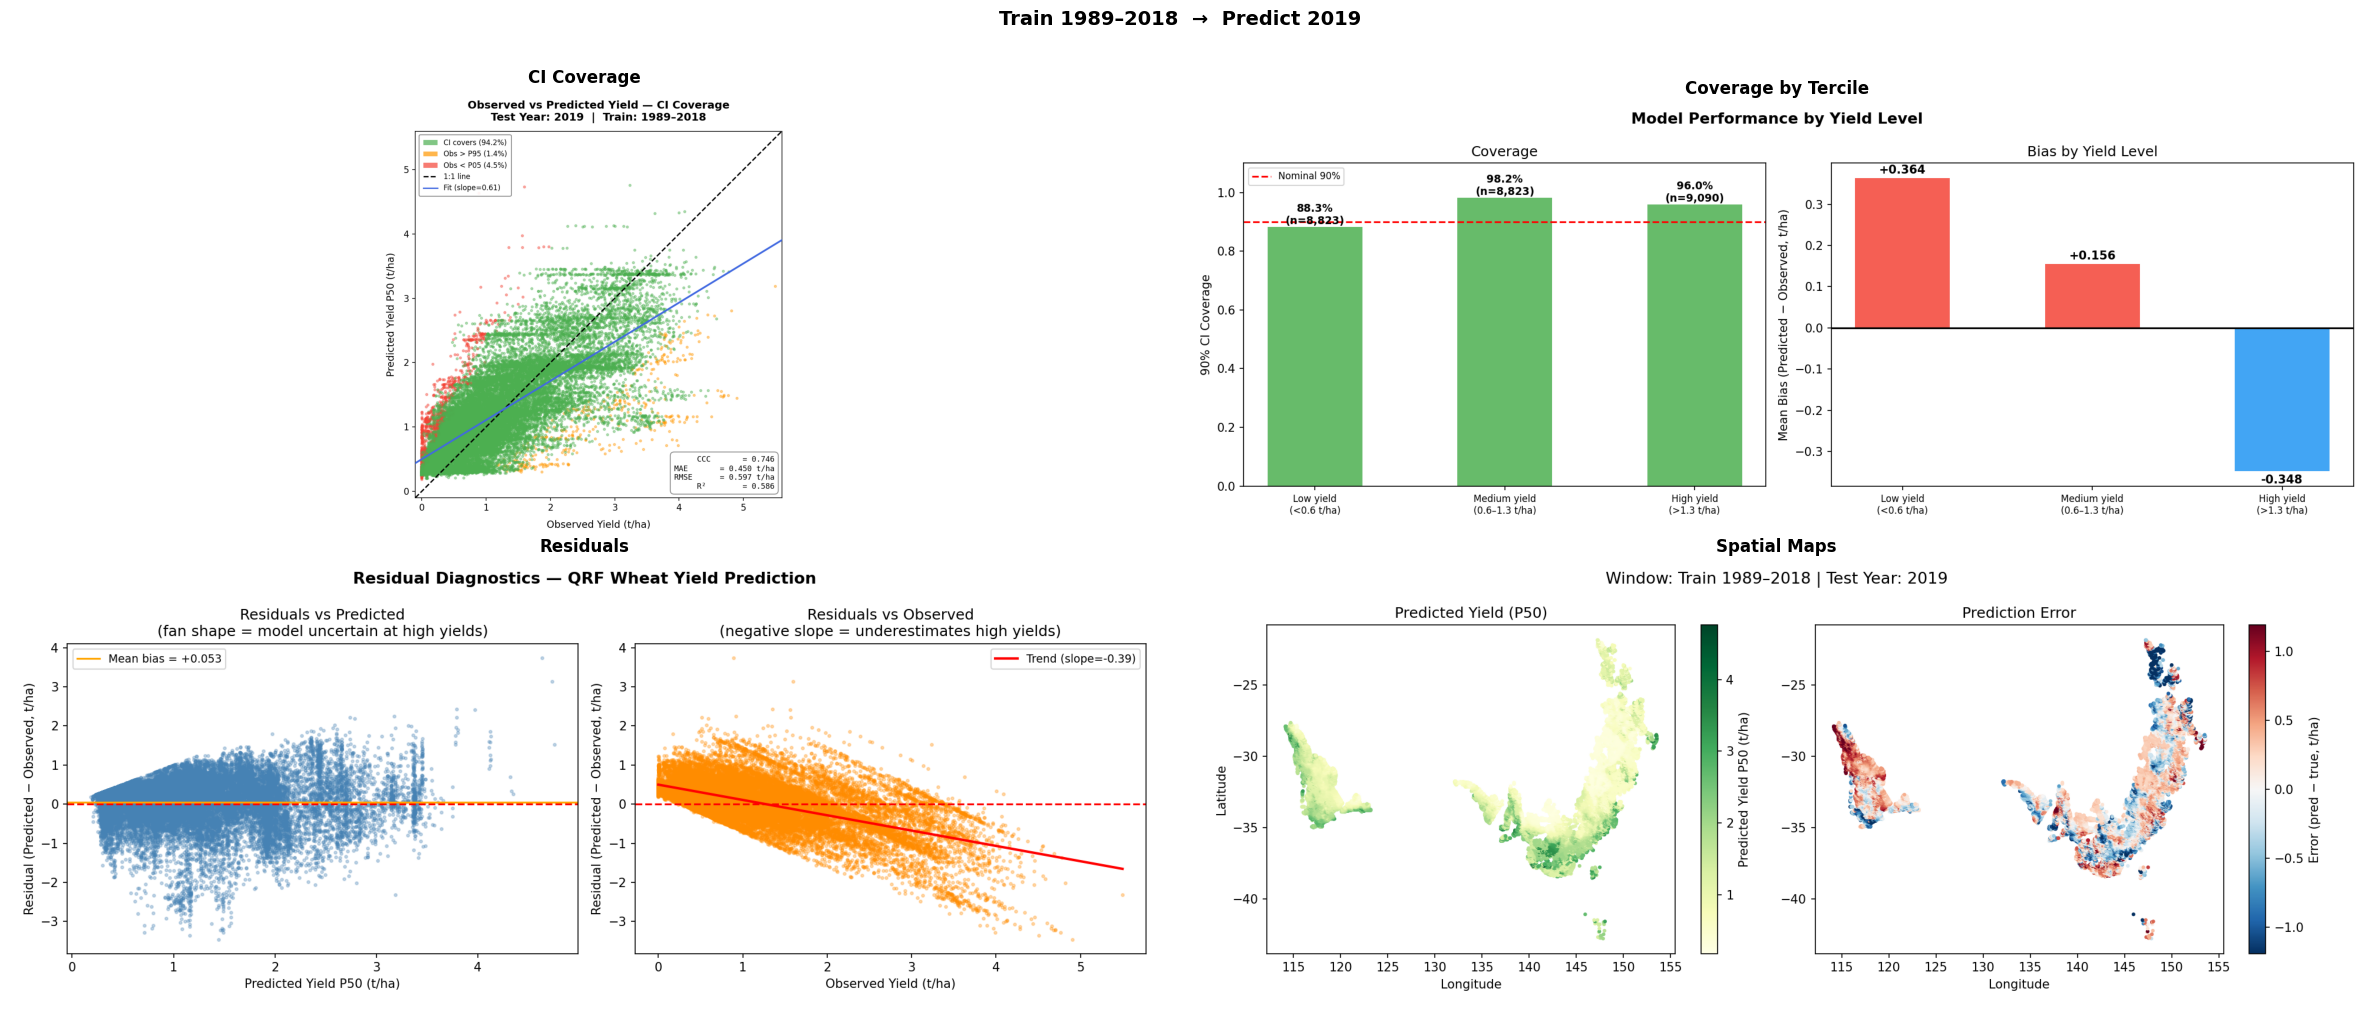

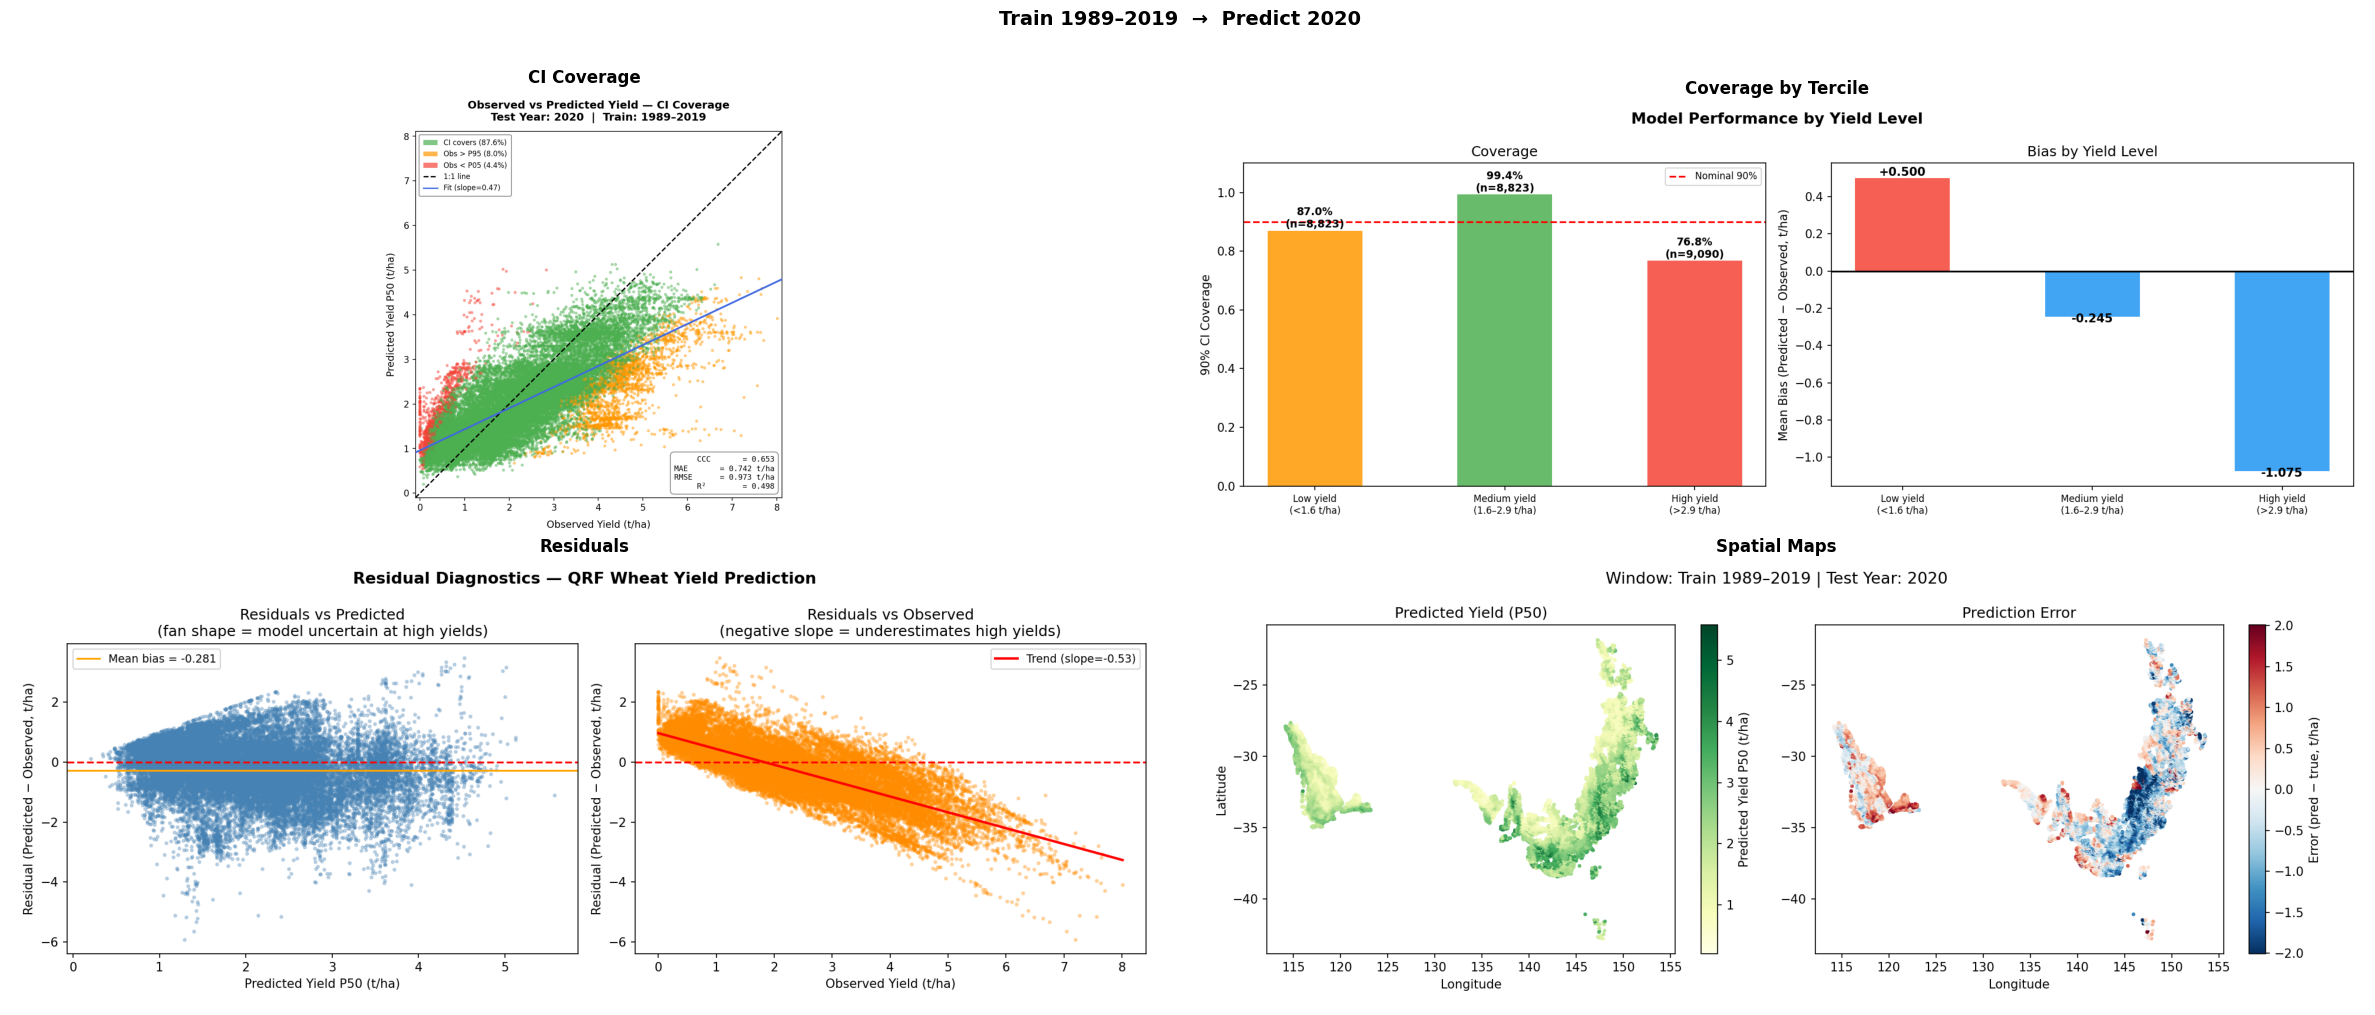

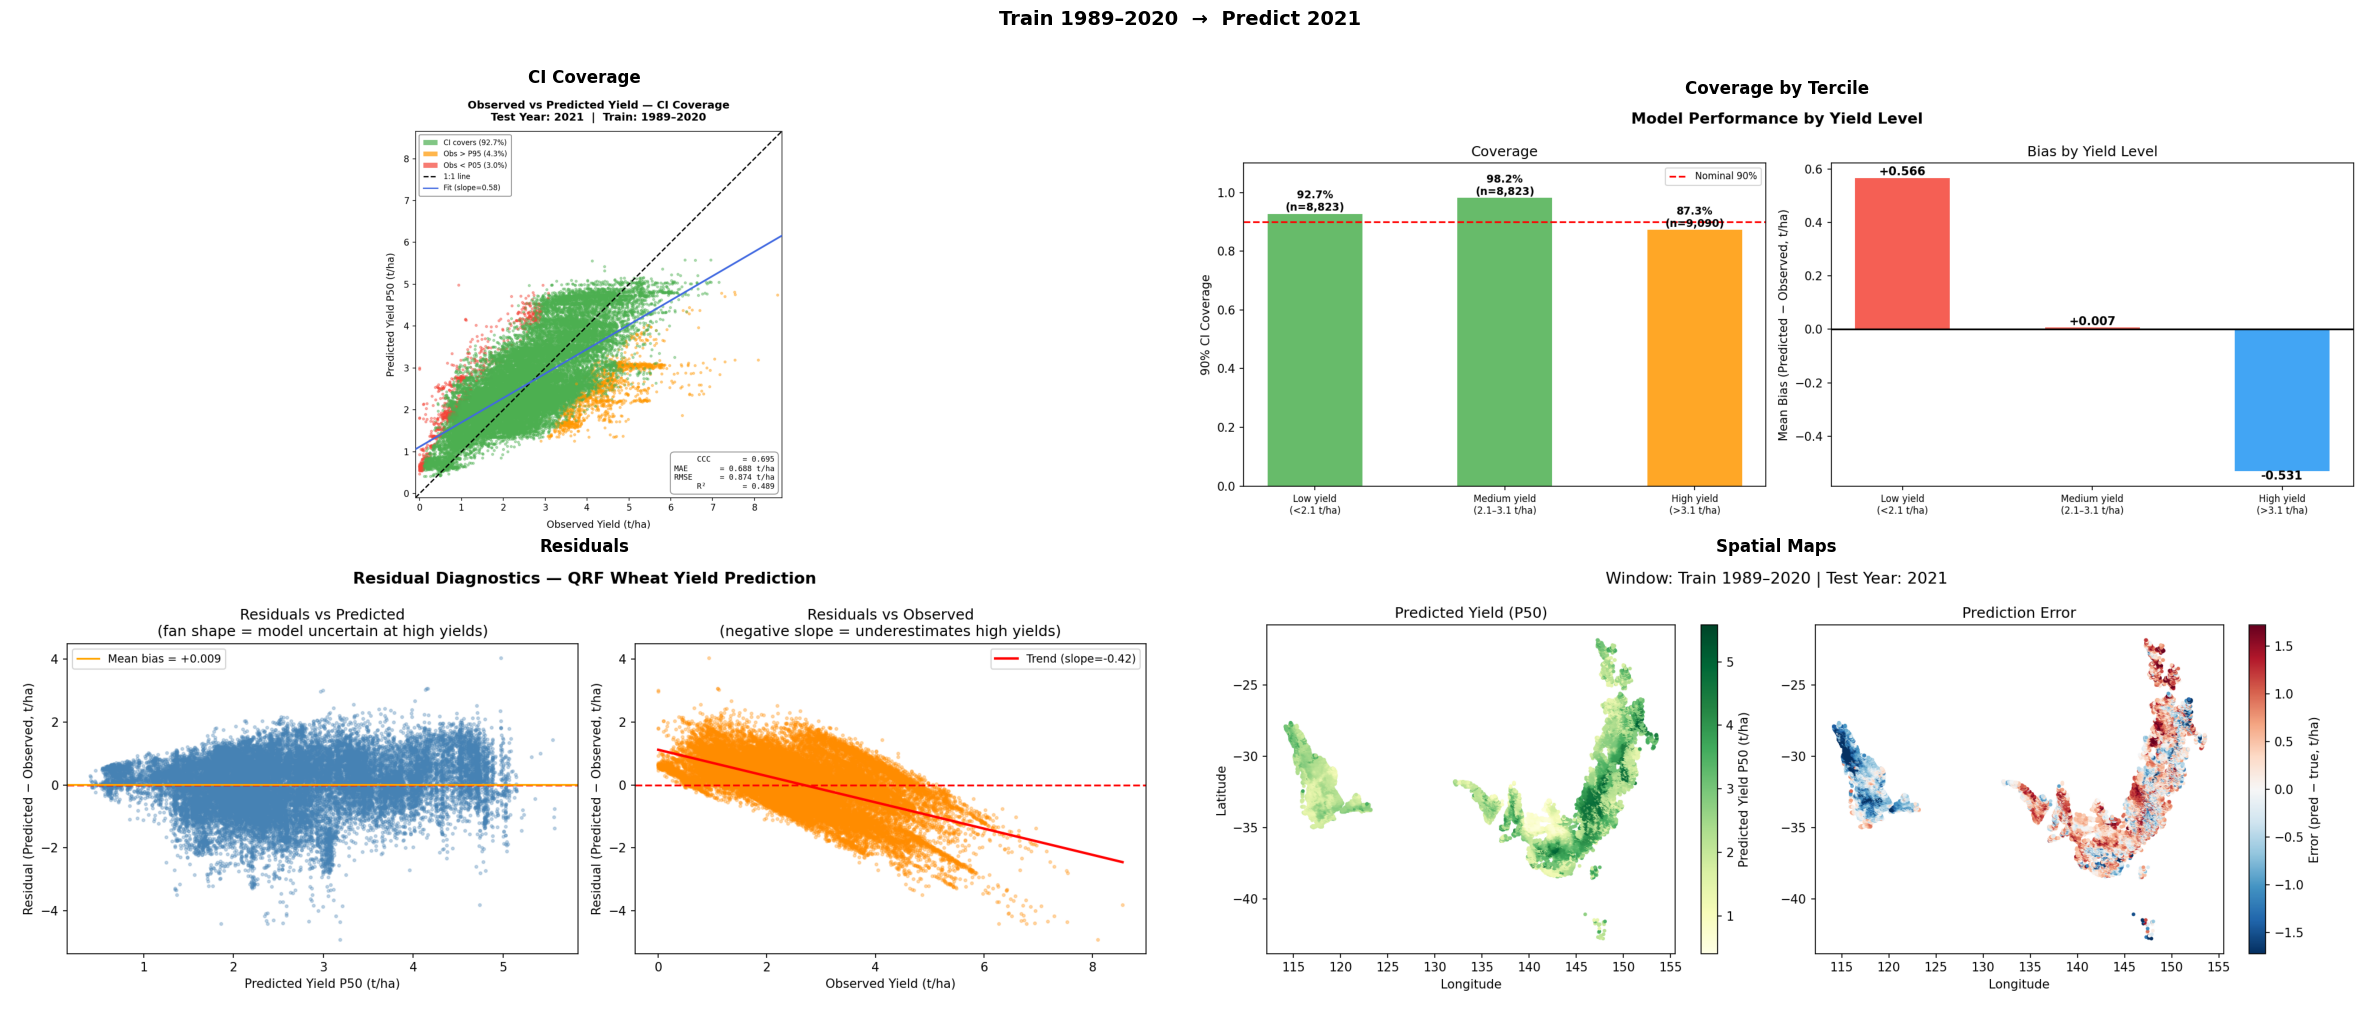

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

FIGS_DIR = Path('../outputs/figures')

next_year_windows = [
    (2016, 2017), (2017, 2018), (2018, 2019), (2019, 2020), (2020, 2021)
]

plots = [  
    ('ci_coverage.png',      'CI Coverage'),
    ('coverage_tercile.png', 'Coverage by Tercile'),
    ('residuals.png',        'Residuals'),
    ('spatial_maps.png',     'Spatial Maps'),
]
  
for train_end, test_year in next_year_windows:
    img_dir = FIGS_DIR / f'train1989_{train_end}' / str(test_year)

    fig, axes = plt.subplots(2, 2, figsize=(24, 10))
    fig.suptitle(f'Train 1989–{train_end}  →  Predict {test_year}',
                 fontsize=14, fontweight='bold', y=1.01)

    for ax, (fname, label) in zip(axes.flat, plots):
        img_path = img_dir / fname
        if img_path.exists():
            ax.imshow(mpimg.imread(img_path))
        else:
            ax.text(0.5, 0.5, f'Not found:\n{fname}',
                    ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label, fontsize=12, fontweight='bold', pad=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [2]:
import pandas as pd

ci = pd.read_csv('../outputs/expanding_window_results/all_ci_coverage_summary.csv')

ci_next = (
    ci[ci['year'] == ci['train_end'] + 1]
    [['year', 'train_end', 'pct_covered', 'ccc', 'pearson_r', 'Cb']]
    .rename(columns={
        'year'       : 'Test Year',
        'train_end'  : 'Train End',
        'pct_covered': 'Coverage (%)',
        'ccc'        : 'LCCC',
        'pearson_r'  : 'Pearson r',
        'Cb'         : 'Cb',
    })
    .reset_index(drop=True)
)

styled = (
    ci_next.style
    .format({'Coverage (%)': '{:.1f}%', 'LCCC': '{:.3f}',
             'Pearson r': '{:.3f}', 'Cb': '{:.3f}'})
    .set_caption('CI Coverage Summary (Horizon = 1)')
    .set_table_styles([{
        'selector': 'td',
        'props': [('text-align','center'), ('font-size','13px'), ('padding','8px 14px')]
    },{
        'selector': 'caption',
        'props': [('font-size','14px'), ('font-weight','bold'),
                  ('color','#ffffff'), ('padding','8px 0')]
    }])
    .hide(axis='index')
)
display(styled)


Test Year,Train End,Coverage (%),LCCC,Pearson r,Cb
2017,2016,90.4%,0.608,0.633,0.960
2018,2017,89.7%,0.612,0.675,0.907
2019,2018,94.2%,0.746,0.768,0.972
2020,2019,87.6%,0.653,0.743,0.880
2021,2020,92.7%,0.695,0.709,0.981


Notes: The uncertainty is well calibrated, the CB is high indicating the prediction centered correctly on the average! However, when looking at bias by tercile, the bias is not good for low and high yield.  Lower CC values likely correspond to predicted years with extrem climate conditions, missing key features impacting to use 

In [4]:
import pandas as pd

metrics = pd.read_csv('../outputs/expanding_window_results/all_metrics.csv')

metrics_next = (
    metrics[metrics['horizon'] == 1]
    [['train_end', 'test_year', 'mae', 'rmse', 'r2']]
    .rename(columns={
        'train_end' : 'Train End',
        'test_year' : 'Test Year',
        'r2'        : 'R²',
        'mae'       : 'MAE (t/ha)',
        'rmse'      : 'RMSE (t/ha)',     
    })
    .reset_index(drop=True)
)

styled = (
    metrics_next.style
    .format({'R²': '{:.3f}','MAE (t/ha)': '{:.3f}', 'RMSE (t/ha)': '{:.3f}'})
    .set_caption('Prediction Accuracy (Horizon = 1)')
    .set_table_styles([{
        'selector': 'td',
        'props': [('text-align','center'), ('font-size','13px'), ('padding','8px 14px')]
    },{
        'selector': 'caption',
        'props': [('font-size','14px'), ('font-weight','bold'),
                  ('color','#ffffff'), ('padding','8px 0')]
    }])
    .hide(axis='index')
)
display(styled)


Train End,Test Year,MAE (t/ha),RMSE (t/ha),R²
2016,2017,0.719,0.889,0.387
2017,2018,0.602,0.764,0.395
2018,2019,0.450,0.597,0.586
2019,2020,0.742,0.973,0.498
2020,2021,0.688,0.874,0.489


# What is next?

- Considering soil moisture data, sowing date rule in APSIM, spatial information (longtitude and latitude)

- Running XGboost for comparison to see if the bias improves in terms of point estimates


### Multi-Horizon performance summary

When the algorithm needs to be retrained?


In [17]:
import pandas as pd

metrics = pd.read_csv('../outputs/expanding_window_results/all_metrics.csv')
ci      = pd.read_csv('../outputs/expanding_window_results/all_ci_coverage_summary.csv')

cb_lookup = ci[['train_end', 'year', 'Cb']].rename(columns={'year': 'test_year'})
df = metrics.merge(cb_lookup, on=['train_end', 'test_year'], how='left')

df['coverage_pct'] = df['coverage_90'] * 100
df['mse']          = df['rmse'] ** 2

table = (
    df[['train_end', 'test_year', 'horizon',
        'coverage_pct', 'ccc', 'pearson_r', 'Cb',
        'r2', 'mae', 'mse', 'rmse']]
    .sort_values(['train_end', 'horizon'])
    .rename(columns={
        'train_end'    : 'Train End',
        'test_year'    : 'Test Year',
        'horizon'      : 'Horizon',
        'coverage_pct' : 'Coverage (%)',
        'ccc'          : 'CCC',
        'pearson_r'    : 'Pearson r',
        'Cb'           : 'Cb',
        'r2'           : 'R²',
        'mae'          : 'MAE (t/ha)',
        'mse'          : 'MSE (t²/ha²)',
        'rmse'         : 'RMSE (t/ha)',
    })
    .reset_index(drop=True)
)

styled = (
    table.style
    .format({
        'Coverage (%)' : '{:.1f}%',
        'CCC'          : '{:.3f}',
        'Pearson r'    : '{:.3f}',
        'Cb'           : '{:.3f}',
        'R²'           : '{:.3f}',
        'MAE (t/ha)'   : '{:.3f}',
        'MSE (t²/ha²)' : '{:.4f}',
        'RMSE (t/ha)'  : '{:.3f}',
    })
    .set_caption('Multi-horizon performance — All training windows × test years')
    .set_table_styles([
        {'selector': 'td',
         'props': [('text-align', 'center'), ('font-size', '13px'), ('padding', '7px 14px')]},
        {'selector': 'th',
         'props': [('text-align', 'center'), ('font-size', '13px'), ('padding', '7px 14px')]},
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'),
                   ('color', '#ffffff'), ('padding', '8px 0')]},
    ])
    .hide(axis='index')
)
display(styled)

Train End,Test Year,Horizon,Coverage (%),CCC,Pearson r,Cb,R²,MAE (t/ha),MSE (t²/ha²),RMSE (t/ha)
2016,2017,1,90.4%,0.608,0.633,0.960,0.387,0.719,0.7905,0.889
2016,2018,2,90.2%,0.615,0.659,0.933,0.381,0.602,0.5973,0.773
2016,2019,3,94.2%,0.757,0.777,0.974,0.600,0.445,0.3447,0.587
2016,2020,4,86.3%,0.646,0.730,0.885,0.490,0.753,0.9636,0.982
2016,2021,5,93.1%,0.695,0.709,0.980,0.490,0.686,0.7618,0.873
2017,2018,1,89.7%,0.612,0.675,0.907,0.395,0.602,0.5834,0.764
2017,2019,2,93.7%,0.753,0.778,0.968,0.598,0.450,0.3465,0.589
2017,2020,3,86.9%,0.651,0.738,0.881,0.497,0.743,0.9508,0.975
2017,2021,4,93.0%,0.693,0.708,0.979,0.489,0.688,0.7634,0.874
2018,2019,1,94.2%,0.746,0.768,0.972,0.586,0.450,0.3569,0.597
